In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns
from pathlib import Path
from itertools import combinations
from collections import defaultdict, Counter
import networkx as nx

In [5]:
all_atom_rmsd = pd.read_parquet("/home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/Analysis/Data/pairwise_method_comparisons_rank1_with_binder_all_atom_rmsd.parquet")
print(all_atom_rmsd.head)

<bound method NDFrame.head of                                          binder_sequence  method_1  \
0      AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...       AF2   
1      AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...       AF2   
2      AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...       AF2   
3      AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...       AF2   
4      AAPEPSEIEKLLEKAFEYLDKLLPVYEAEDLSEETKNYIFLSIART...       AF2   
...                                                  ...       ...   
14401  YVQLMERGGGLVQAGGSLRLQCAASGRTFSSYAMGWFRQAPGRERE...       OF2   
14402  YVQLMERGGGLVQAGGSLRLQCAASGRTFSSYAMGWFRQAPGRERE...       OF2   
14403  YVQLMERGGGLVQAGGSLRLQCAASGRTFSSYAMGWFRQAPGRERE...       OF3   
14404  YVQLMERGGGLVQAGGSLRLQCAASGRTFSSYAMGWFRQAPGRERE...       OF3   
14405  YVQLMERGGGLVQAGGSLRLQCAASGRTFSSYAMGWFRQAPGRERE...  Protenix   

         method_2                                   structure_path_1  \
0             AF3  /home/postyr/Assessing-AI-Scoring-Accu

In [6]:
df_csv = pd.read_csv("/home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/results_old/AdaptyvBio/contest_2_round_2_metrics_summary.csv")

In [7]:
rmsd_merged = all_atom_rmsd.merge(df_csv[["sequence", "design_class", "binding"]], how="left", left_on="binder_sequence", right_on="sequence")
rmsd_merged = rmsd_merged.drop(columns=["sequence"])

In [8]:
plot_rmsd = rmsd_merged[rmsd_merged["design_class"].isin(["Miniprotein", "Peptide"])].copy()

In [9]:
rmsd_col = "binder_all_atom_rmsd_align_binder"

rmsd_median = (
    plot_rmsd
    .groupby(["method_1", "method_2"], as_index=False)[rmsd_col]
    .median()
    .rename(columns={rmsd_col: "pair_median_rmsd_all_atom"})
)

rmsd_median.head()

,method_1,method_2,pair_median_rmsd_all_atom
0,AF2,AF3,1.298564
1,AF2,Boltz-2,2.087190
2,AF2,Chai-1,1.936156
3,AF2,HelixFold3,6.084458
4,AF2,OF2,10.152203


In [10]:
plot_rmsd_with_median = plot_rmsd.merge(rmsd_median, on=["method_1", "method_2"], how="left")

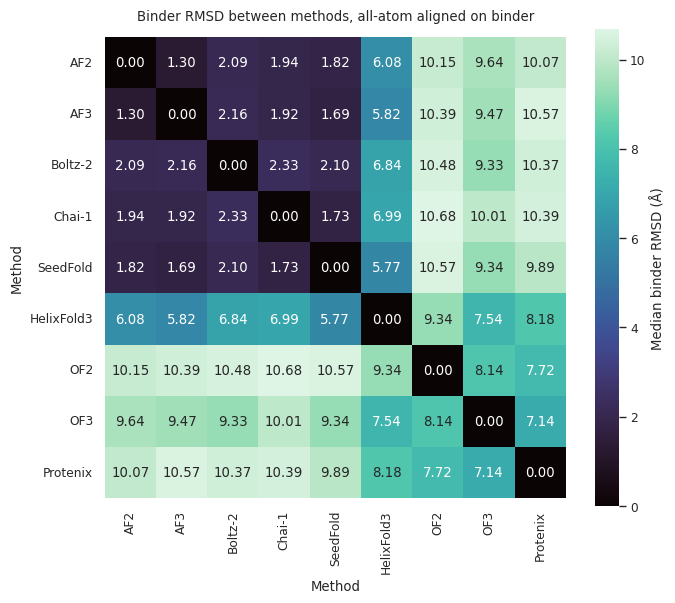

In [11]:
rmsd_col = "binder_all_atom_rmsd_align_binder"

rmsd_matrix = (
    plot_rmsd
    .groupby(["method_1", "method_2"])[rmsd_col]
    .median()
    .unstack()
)

rmsd_matrix = rmsd_matrix.combine_first(rmsd_matrix.T)

method_order = [
    "AF2", "AF3", "Boltz-2", "Chai-1",
    "SeedFold", "HelixFold3",
    "OF2", "OF3", "Protenix"
]
rmsd_matrix = rmsd_matrix.reindex(index=method_order, columns=method_order)

for m in rmsd_matrix.index:
    rmsd_matrix.loc[m, m] = 0.0

sns.set_theme(style="white", context="paper")

plt.figure(figsize=(7, 6))
ax = sns.heatmap(
    rmsd_matrix,
    cmap="mako",
    annot=True,
    fmt=".2f",
    square=True,
    cbar_kws={"label": "Median binder RMSD (Å)"}
)

ax.set_title("Binder RMSD between methods, all-atom aligned on binder", pad=12)
ax.set_xlabel("Method")
ax.set_ylabel("Method")

plt.tight_layout()
plt.show()

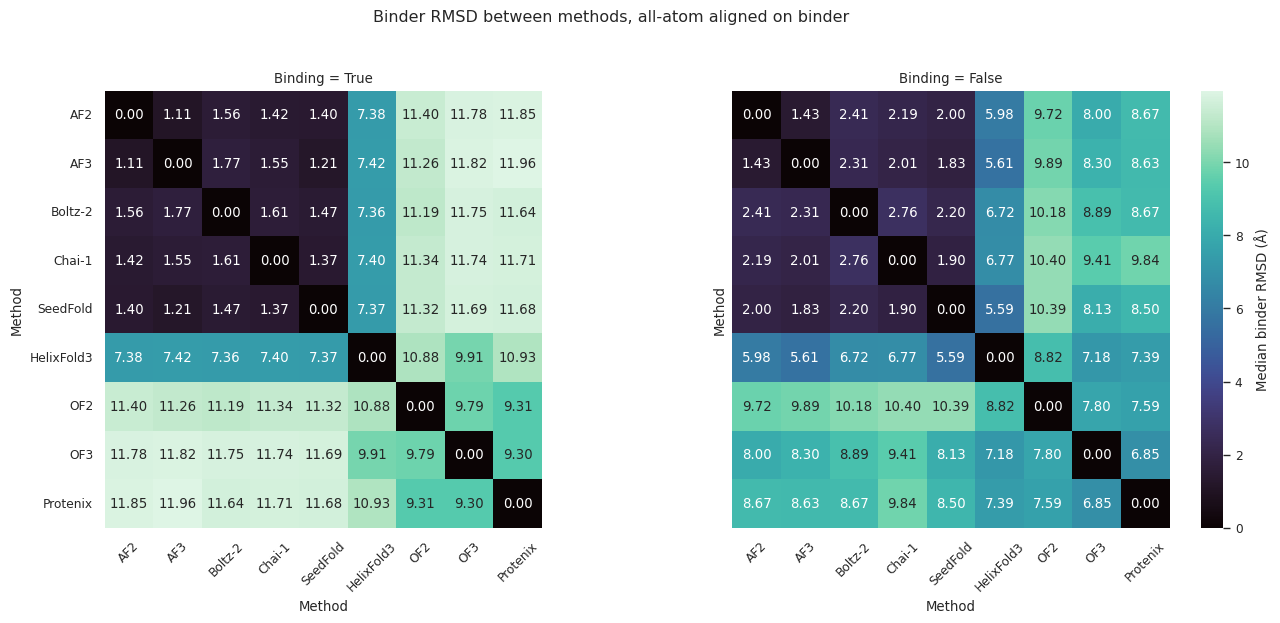

In [13]:
rmsd_col = "binder_all_atom_rmsd_align_binder"

method_order = [
    "AF2", "AF3", "Boltz-2", "Chai-1",
    "SeedFold", "HelixFold3",
    "OF2", "OF3", "Protenix"
]

def make_rmsd_matrix(df):
    matrix = (
        df
        .groupby(["method_1", "method_2"])[rmsd_col]
        .median()
        .unstack()
    )

    matrix = matrix.combine_first(matrix.T)
    matrix = matrix.reindex(index=method_order, columns=method_order)

    for m in matrix.index:
        matrix.loc[m, m] = 0.0

    return matrix


binding_matrix = make_rmsd_matrix(plot_rmsd[plot_rmsd["binding"] == True])
nonbinding_matrix = make_rmsd_matrix(plot_rmsd[plot_rmsd["binding"] == False])

sns.set_theme(style="white", context="paper")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

vmin = min(binding_matrix.min().min(), nonbinding_matrix.min().min())
vmax = max(binding_matrix.max().max(), nonbinding_matrix.max().max())

sns.heatmap(
    binding_matrix,
    ax=axes[0],
    cmap="mako",
    annot=True,
    fmt=".2f",
    square=True,
    vmin=vmin,
    vmax=vmax,
    cbar=False
)

sns.heatmap(
    nonbinding_matrix,
    ax=axes[1],
    cmap="mako",
    annot=True,
    fmt=".2f",
    square=True,
    vmin=vmin,
    vmax=vmax,
    cbar_kws={"label": "Median binder RMSD (Å)"}
)

axes[0].set_title("Binding = True")
axes[1].set_title("Binding = False")

for ax in axes:
    ax.set_xlabel("Method")
    ax.set_ylabel("Method")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

fig.suptitle("Binder RMSD between methods, all-atom aligned on binder", y=1.03)

plt.tight_layout()
plt.show()